In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/sports-classification")

print("Path to dataset files:", path)

100%|██████████| 424M/424M [00:15<00:00, 28.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9


In [3]:
import kagglehub
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download("gpiosenka/sports-classification")
print("Dataset path:", path)

Using Colab cache for faster access to the 'sports-classification' dataset.
Dataset path: /kaggle/input/sports-classification


Total Images: 14492


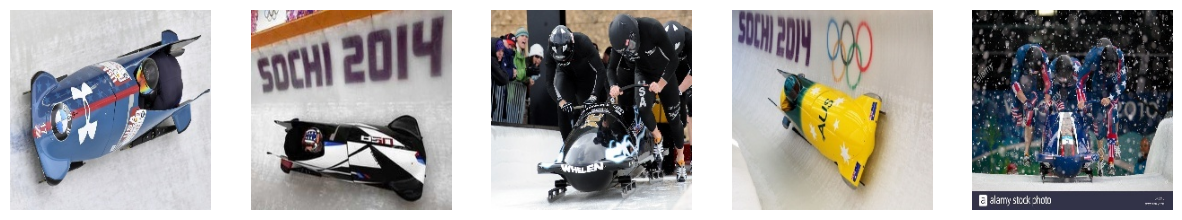

In [4]:
#Load and visualize at least five images.
import os
import cv2
import matplotlib.pyplot as plt

image_paths = []

# Collect image files
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Total Images:", len(image_paths))

# Display first 5 images
plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [10]:
# Extract image height, width, and channels and store in a table
data = []

for img_path in image_paths[:20]:   # first 20 images for demonstration
    img = cv2.imread(img_path)

    height, width, channels = img.shape

    data.append([
        os.path.basename(img_path),
        height,
        width,
        channels
    ])

df = pd.DataFrame(
    data,
    columns=["Image Name", "Height", "Width", "Channels"]
)

df.head(20)

,Image Name,Height,Width,Channels
0,5.jpg,224,224,3
1,1.jpg,224,224,3
2,4.jpg,224,224,3
3,3.jpg,224,224,3
4,2.jpg,224,224,3
5,5.jpg,224,224,3
6,1.jpg,224,224,3
7,4.jpg,224,224,3
8,3.jpg,224,224,3
9,2.jpg,224,224,3


In [6]:
#Resize all images to 224×224 pixels.
resized_images = []

for img_path in image_paths:
    img = cv2.imread(img_path)

    resized = cv2.resize(img, (224,224))

    resized_images.append(resized)

print("Total resized images:", len(resized_images))
print("Shape of first resized image:", resized_images[0].shape)

Total resized images: 14492
Shape of first resized image: (224, 224, 3)


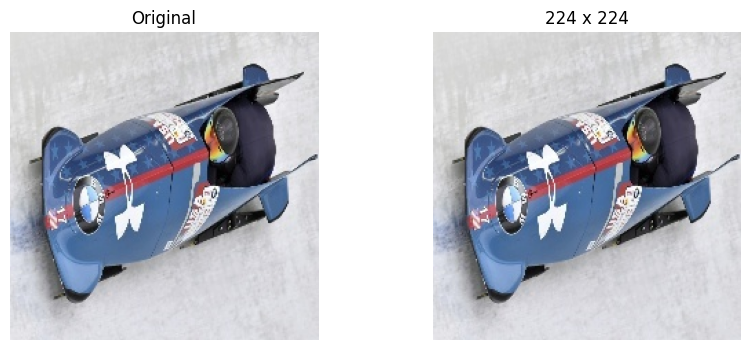

In [7]:

img = cv2.imread(image_paths[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

resized = cv2.resize(img_rgb, (224,224))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title("224 x 224")
plt.axis("off")

plt.show()

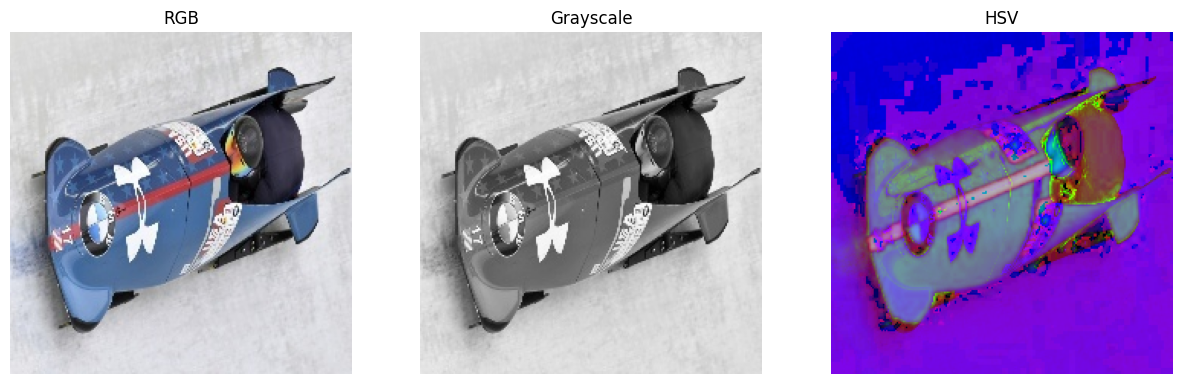

In [8]:
# Convert images to Grayscale, RGB, and HSV
img = cv2.imread(image_paths[0])

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

In [9]:
 #Normalize pixel values from 0–255 to 0–1.

img = cv2.imread(image_paths[0])

normalized = img / 255.0

print("Before Normalization")
print("Min:", img.min(), "Max:", img.max())

print("\nAfter Normalization")
print("Min:", normalized.min(), "Max:", normalized.max())

Before Normalization
Min: 0 Max: 255

After Normalization
Min: 0.0 Max: 1.0


In [13]:
# Perform Data Augmentation (rotation, flips, zoom, brightness adjustment).
from PIL import Image, ImageEnhance, ImageOps
import os
import matplotlib.pyplot as plt

# Load sample image
image_path = image_paths[0]   # use any image from dataset
image = Image.open(image_path)

# Create folder for augmented images
augmented_dir = "augmented_images"
os.makedirs(augmented_dir, exist_ok=True)

# 1. Horizontal Flip
flipped = ImageOps.mirror(image)
flipped.save(os.path.join(augmented_dir, "flipped.jpg"))

# 2. Rotation
rotated = image.rotate(30)
rotated.save(os.path.join(augmented_dir, "rotated.jpg"))

# 3. Brightness Adjustment
bright = ImageEnhance.Brightness(image).enhance(1.5)
bright.save(os.path.join(augmented_dir, "bright.jpg"))

# 4. Zoom
width, height = image.size

zoom_factor = 1.3

new_width = int(width / zoom_factor)
new_height = int(height / zoom_factor)

left = (width - new_width) // 2
top = (height - new_height) // 2
right = left + new_width
bottom = top + new_height

zoomed = image.crop((left, top, right, bottom))
zoomed = zoomed.resize((width, height))

zoomed.save(os.path.join(augmented_dir, "zoomed.jpg"))

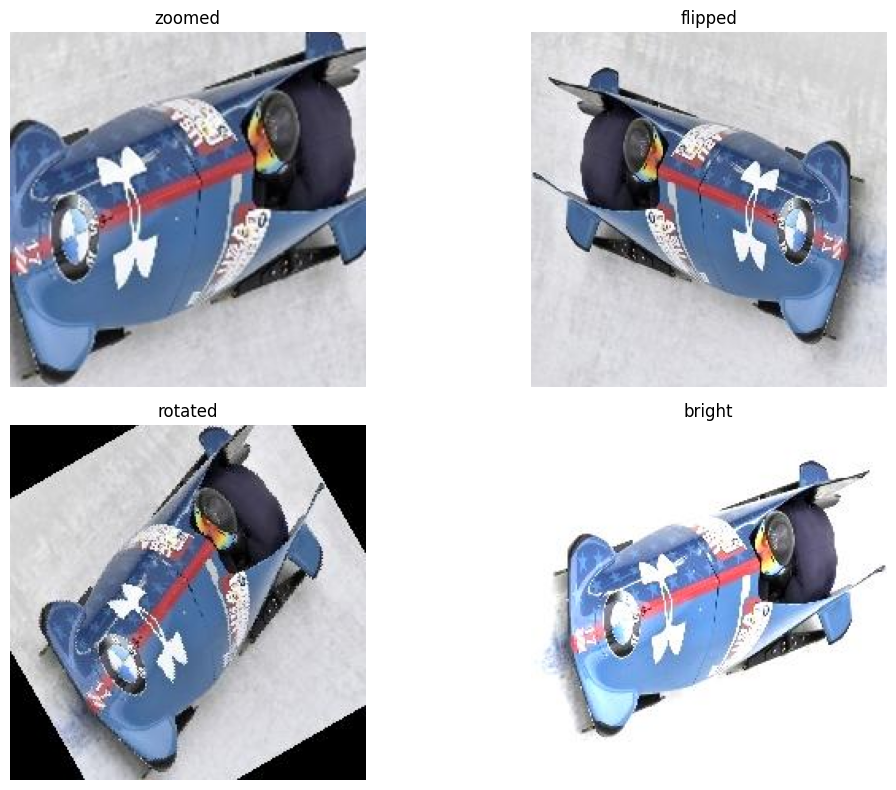

In [12]:
augmented_images = os.listdir(augmented_dir)

plt.figure(figsize=(12,8))

for i, img_file in enumerate(augmented_images):

    img_path = os.path.join(augmented_dir, img_file)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(img_file.split('.')[0])

    plt.axis("off")

plt.tight_layout()
plt.show()


In [16]:
def preprocess_image(image_path):

    image = cv2.imread(image_path)

    resized = cv2.resize(image, (224,224))

    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    normalized = rgb / 255.0

    gaussian = cv2.GaussianBlur(rgb, (5,5), 0)
    median = cv2.medianBlur(rgb, 5)

    return rgb, gray, hsv, normalized, gaussian, median

In [17]:
rgb, gray, hsv, normalized, gaussian, median = preprocess_image(image_paths[0])

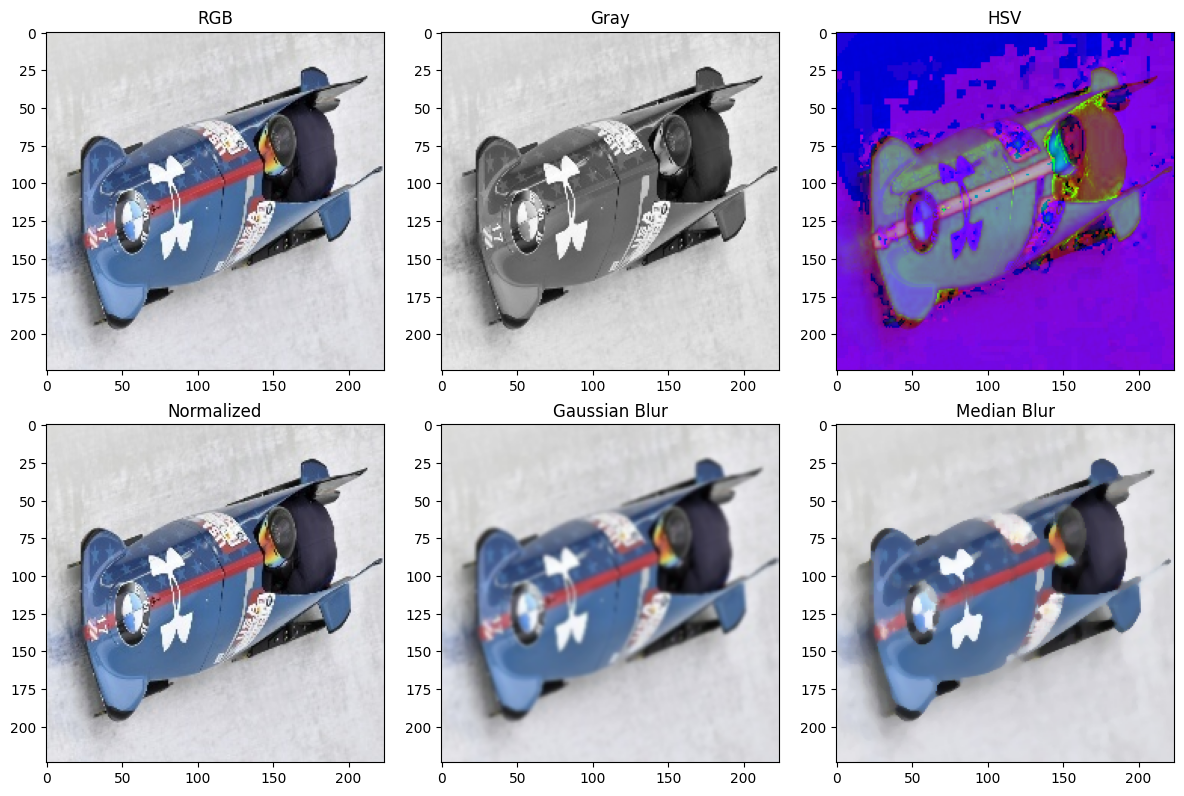

In [18]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(rgb)
plt.title("RGB")

plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")

plt.subplot(2,3,3)
plt.imshow(hsv)
plt.title("HSV")

plt.subplot(2,3,4)
plt.imshow(normalized)
plt.title("Normalized")

plt.subplot(2,3,5)
plt.imshow(gaussian)
plt.title("Gaussian Blur")

plt.subplot(2,3,6)
plt.imshow(median)
plt.title("Median Blur")

plt.tight_layout()
plt.show()